## cafe5 model fitting & selection

- --> fit a suite of birth–death models to the filtered families on the dated tree, then choose the best by **AIC**

CAFE5 options used:

| flag | meaning |
|---|---|
| `-p` | estimate the **root frequency** distribution (Poisson) instead of assuming uniform |
| `-e` | estimate a genome-**error model** (assembly/annotation error inflates λ) |
| `-k n` | **Gamma** model — `n` discrete rate categories for **among-family rate variation (AFRV)** |
| `-y` | **multi-λ** — separate λ per branch class from a lambda tree (marine *Hydrophis* vs background) |

### Models
| id | command tail | tests |
|---|---|---|
| Base | `-p` | single genome-wide λ |
| Base+error | `-p -e` | + assembly error |
| Gamma k2 | `-p -k 2` | families fall in 2 rate classes |
| Gamma k3 | `-p -k 3` | 3 rate classes |
| Multi-λ | `-p -y λtree` | marine vs terrestrial λ |
| Gamma k3+error | `-p -k 3 -e<model>` | AFRV + error |
| Multi-λ+error | `-p -y λtree -e<model>` | marine λ + error |


In [1]:
import os, re, glob, subprocess, math, pandas as pd

CAFE="/hpcfs/users/a1864358/sanders_lab/phylogenomics/cafe"; C5="/hpcfs/users/a1864358/miniconda/envs/v2r_phylo/bin/cafe5"; os.chdir(CAFE)
CNT="inputs/cafe_counts_filtered.tsv"; TREE="trees/species_tree_ultrametric.nwk"; LT="trees/lambda_tree_marine.txt"

def run_if_missing(outdir, tail):
    if os.path.isdir(outdir) and os.path.exists(f"{outdir}/Base_results.txt".replace("Base_results","Base_results")) or glob.glob(f"{outdir}/*_results.txt"):
        print("exists:", outdir); return
    cmd=f"{C5} -i {CNT} -t {TREE} {tail} -c 16 -o {outdir}"
    print("$", cmd); subprocess.run(cmd, shell=True)
    

print("cafe5 runs present:", [os.path.basename(d) for d in glob.glob('runs/*') if os.path.isdir(d)])

cafe5 runs present: ['gamma_k5_error', 'multilambda_error', 'gamma_k4_error_rep2', 'large', 'gamma_k3', 'gamma_k3_error', 'gamma_k4_error', 'base_multical', 'multilambda_multical', 'base_error', 'multilambda', 'base', 'gamma_k2', 'best_rep2']


## Parse every model's result file
CAFE writes `Base_results.txt` or `Gamma_results.txt` with the final `-lnL`, λ(s), α (Gamma) and ε (error).

In [2]:
def results_file(d):
    for pref in ("Base","Gamma"):
        p=os.path.join(d,pref+"_results.txt")
        if os.path.exists(p): return p
    return None

def parse_run(d):
    f = results_file(d)
    if not f: return None
    txt = open(f).read()
    def num(pat):
        m=re.search(pat, txt); return float(m.group(1)) if m else None
    lnl   = num(r"Final Likelihood \(-lnL\):\s*([0-9.eE+-]+)")
    lam   = re.findall(r"Lambda:\s*([0-9.,eE+\- ]+)", txt)
    alpha = num(r"Alpha:\s*([0-9.eE+-]+)")
    eps   = num(r"Epsilon:\s*([0-9.eE+-]+)")
    lams  = [float(x) for x in re.split(r"[,\s]+", lam[0].strip())] if lam else []
    return dict(dir=os.path.basename(d), neglnL=lnl, lambdas=lams, n_lambda=len(lams), alpha=alpha, epsilon=eps, model=os.path.basename(f).split("_")[0])

runs = {
 "Base":"runs/base", "Base+error":"runs/base_error", "Gamma k2":"runs/gamma_k2",
 "Gamma k3":"runs/gamma_k3", "Multi-λ":"runs/multilambda",
 "Gamma k3+error":"runs/gamma_k3_error", "Multi-λ+error":"runs/multilambda_error",
 "Gamma k4+error":"runs/gamma_k4_error", "Gamma k5+error":"runs/gamma_k5_error"}
rows=[]
for name,d in runs.items():
    p=parse_run(d)
    if p: p["name"]=name; rows.append(p)
res=pd.DataFrame(rows)
res

,dir,neglnL,lambdas,n_lambda,alpha,epsilon,model,name
0,base,71900.9,[0.00081501617334216],1,NaN,NaN,Base,Base
1,base_error,67773.2,[0.00050714265887035],1,NaN,0.01357,Base,Base+error
2,gamma_k2,66758.2,[0.0012275404675997],1,0.314266,NaN,Gamma,Gamma k2
3,gamma_k3,65699.8,[0.0021393987232183],1,0.361055,NaN,Gamma,Gamma k3
4,multilambda,69120.0,"[0.00065843642040617, 0.004459899548372]",2,NaN,NaN,Base,Multi-λ
5,gamma_k3_error,63178.0,[0.0020898840835721],1,0.341893,0.01357,Gamma,Gamma k3+error
6,multilambda_error,66628.0,"[0.00042615180855607, 0.0026377875675116]",2,NaN,0.01357,Base,Multi-λ+error
7,gamma_k4_error,62842.2,[0.00091887112216861],1,0.526226,0.01357,Gamma,Gamma k4+error
8,gamma_k5_error,62882.6,[0.00080409727289695],1,0.631654,0.01357,Gamma,Gamma k5+error


## Model selection by AIC
`AIC = 2k + 2·(−lnL)`

Free parameters `k`: λ count `+` α (if Gamma) `+` ε (if error) `+` 1 root-frequency (all models use `-p`)

- `k` here is CAFE's number of free parameters, unrelated to `Gamma k=N` (the number of rate categories)

In [ ]:
def npar(r):
    return r["n_lambda"] + (1 if r["alpha"] else 0) + (1 if r["epsilon"] else 0) + 1

res["k"]=res.apply(npar,axis=1)
res["AIC"]=2*res["k"]+2*res["neglnL"]
res["dAIC"]=res["AIC"]-res["AIC"].min()
best=res.sort_values("AIC").iloc[0]
show=res.sort_values("AIC")[["name","model","neglnL","n_lambda","alpha","epsilon","k","AIC","dAIC"]].round(3)
print("Lowest raw AIC:", best["name"], " (ΔAIC=0)")
show

Lowest raw AIC: Gamma k4+error  (ΔAIC=0)


,name,model,neglnL,n_lambda,alpha,epsilon,k,AIC,dAIC
7,Gamma k4+error,Gamma,62842.2,1,0.526,0.014,4,125692.4,0.0
8,Gamma k5+error,Gamma,62882.6,1,0.632,0.014,4,125773.2,80.8
5,Gamma k3+error,Gamma,63178.0,1,0.342,0.014,4,126364.0,671.6
3,Gamma k3,Gamma,65699.8,1,0.361,NaN,4,131407.6,5715.2
6,Multi-λ+error,Base,66628.0,2,NaN,0.014,5,133266.0,7573.6
2,Gamma k2,Gamma,66758.2,1,0.314,NaN,4,133524.4,7832.0
1,Base+error,Base,67773.2,1,NaN,0.014,4,135554.4,9862.0
4,Multi-λ,Base,69120.0,2,NaN,NaN,5,138250.0,12557.6
0,Base,Base,71900.9,1,NaN,NaN,4,143809.8,18117.4


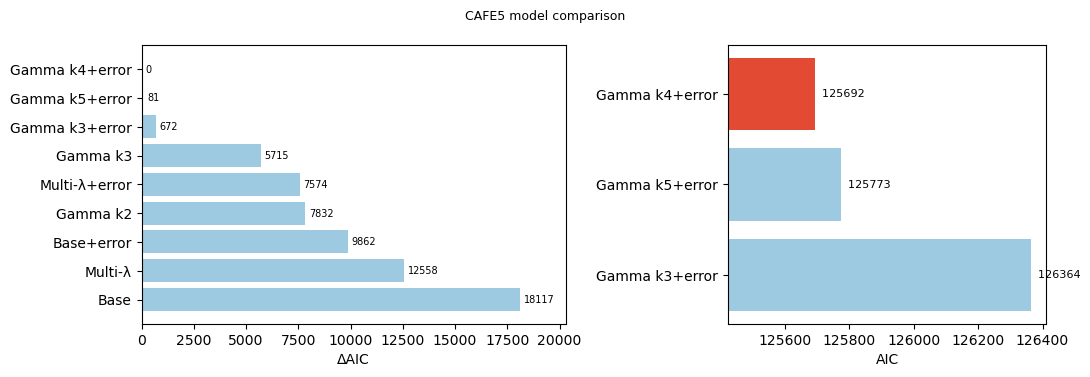

In [11]:
import matplotlib.pyplot as plt

s = res.sort_values("AIC")
REPORTED = "Gamma k4+error"          
def cols(sub): return ["#e34a33" if n==REPORTED else "#9ecae1" for n in sub["name"]]

fig,(ax1,ax2) = plt.subplots(1,2, figsize=(11,3.8), gridspec_kw={"width_ratios":[2,1.5]})

ax1.barh(s["name"], s["dAIC"], color=cols(s)); ax1.invert_yaxis()
ax1.set_xlabel("ΔAIC")
ax1.set_xlim(0, s["dAIC"].max()*1.12)
for y,v in enumerate(s["dAIC"]): ax1.text(v+s["dAIC"].max()*0.01, y, f"{v:.0f}", va="center", fontsize=7)

top = s[s["dAIC"] < 1200].copy()
base = top["AIC"].min() - (top["AIC"].max()-top["AIC"].min())*0.4   # baseline just below best
ax2.barh(top["name"], top["AIC"]-base, left=base, color=cols(top)); ax2.invert_yaxis()
ax2.set_xlim(base, top["AIC"].max()+ (top["AIC"].max()-base)*0.05)
ax2.set_xlabel("AIC")
for y,v in zip(range(len(top)), top["AIC"]): ax2.text(v, y, f"  {v:.0f}", va="center", fontsize=8)
fig.suptitle("CAFE5 model comparison", fontsize=9)
plt.tight_layout(); plt.savefig("figures/nb2_model_AIC.png", dpi=130); plt.show()

## Likelihood-ratio test — does the marine *Hydrophis* clade have a distinct λ?
Multi-λ (marine vs background) vs Base (single λ): `LR = 2(lnL_base − lnL_multi)`, `df = n_λ − 1`, χ².

In [5]:
from scipy.stats import chi2

b = res.set_index("name")
if "Multi-λ" in b.index and "Base" in b.index:
    LR = 2*(b.loc["Base","neglnL"] - b.loc["Multi-λ","neglnL"])
    df = b.loc["Multi-λ","n_lambda"] - 1
    p  = chi2.sf(LR, df)
    print(f"Base λ            = {b.loc['Base','lambdas']}")
    print(f"Multi-λ (bg,marine)= {b.loc['Multi-λ','lambdas']}")
    print(f"LR = {LR:.3f}, df = {df}, p = {p:.3g}")
    print("=> marine Hydrophis λ significantly different" if p<0.05 else "=> no significant λ difference")

Base λ            = [0.00081501617334216]
Multi-λ (bg,marine)= [0.00065843642040617, 0.004459899548372]
LR = 5561.800, df = 1, p = 0
=> marine Hydrophis λ significantly different


## Large families (≥100 copies) — analysed separately with fixed λ
Uses the best single λ from the Base model, per CAFE convention.

In [6]:
lam_base = res.set_index("name").loc["Base","lambdas"][0]
if not glob.glob("runs/large/*_results.txt"):
    cmd=f"{C5} -i inputs/cafe_counts_large.tsv -t {TREE} -p -l {lam_base} -c 16 -o runs/large"
    print("$",cmd); subprocess.run(cmd,shell=True)

print("large-family clade results:")
print(open('runs/large/Base_clade_results.txt').read() if os.path.exists('runs/large/Base_clade_results.txt') else "see runs/large/")

large-family clade results:
see runs/large/


## Convergence check (best model, replicate)
CAFE docs advise multiple runs for Gamma/multi-λ. We re-fit the best model and confirm the likelihood/λ are stable.

In [ ]:
import glob, subprocess, os
REPORTED_DIR = "gamma_k4_error"          # the model we use downstream
tailmap = {"base":"-p", "base_error":"-p -e", "gamma_k2":"-p -k 2", "gamma_k3":"-p -k 3",
           "multilambda":f"-p -y {LT}",
           "gamma_k3_error":"-p -k 3 -eruns/base_error/Base_error_model.txt",
           "gamma_k4_error":"-p -k 4 -eruns/base_error/Base_error_model.txt",
           "gamma_k5_error":"-p -k 5 -eruns/base_error/Base_error_model.txt",
           "multilambda_error":f"-p -y {LT} -eruns/base_error/Base_error_model.txt"}

tail = tailmap[REPORTED_DIR]
repdir = f"runs/{REPORTED_DIR}_rep2"
if not glob.glob(f"{repdir}/*_results.txt"):
    print("running replicate:", f"{C5} -i {CNT} -t {TREE} {tail} -c 16 -o {repdir}")
    subprocess.run(f"{C5} -i {CNT} -t {TREE} {tail} -c 16 -o {repdir}", shell=True)
r1 = parse_run("runs/"+REPORTED_DIR); r2 = parse_run(repdir)
print("reported model:", REPORTED_DIR, "| tail:", tail)
print(f"rep1  -lnL {r1['neglnL']}   alpha {r1['alpha']}")
print(f"rep2  -lnL {r2['neglnL']}   alpha {r2['alpha']}")
print(f"replicate spread: {abs(r1['neglnL']-r2['neglnL']):.1f} -lnL units "
      f"(optimizer local-optimum noise)")

reported model: gamma_k4_error | tail: -p -k 4 -eruns/base_error/Base_error_model.txt
rep1  -lnL 62842.2   alpha 0.526226
rep2  -lnL 62914.3   alpha 0.55131
replicate spread: 72.1 -lnL units (optimizer local-optimum noise)


In [8]:
res.to_csv("analysis/model_comparison.tsv",sep="\t",index=False)
print("saved analysis/model_comparison.tsv"); print("Best model dir ->", res.sort_values('AIC').iloc[0]['dir'])

saved analysis/model_comparison.tsv
Best model dir -> gamma_k4_error
